In [13]:
import torch
from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import (
    HydrAMPEncoderDecoder,
)
from pep_compass.models.encoder_decoder.utils import decoder_jacobian
from pep_compass.local_enumeration.mutation.utils import get_mutations_from_s_u_standard
from pep_compass.local_enumeration.sampling.sorbes import SubRiemannianTangentSpace

from pep_compass.local_enumeration.mutation.mutation_potentials import (
    compose_mutant_distribution,
    ProjectedDirectionPairwiseSimilarityPotential,
    DecoderLogProbPotential
)

In [14]:
device = torch.device("cpu")
hydramp = HydrAMPEncoderDecoder(
    jacobian_mode="approx",
    jacobian_eps=1e-6,
    field_eps=1e-6,
    device=device,
)
peps = ["FLYKWWIRIGRLKL", "KYCRRFRWLTFRWL", "KFRNRHRWKFKLIFRN", "KKYWLIRKWIRLWFLT", "KTLKIIRLLF", "RMARNLVRYVQGLKKKKVI"]

In [15]:
peptide = peps[1]
pep_len = len(peptide)
z = hydramp.encode_peptides([peptide])
print(f"Parent: {peptide}")
print(f"Latent shape: {z.shape}")

Parent: KYCRRFRWLTFRWL
Latent shape: torch.Size([1, 64])


In [16]:
jac = decoder_jacobian(
    lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
    z,
    jacobian_fn_mode="approx",
    jacobian_fn_kwargs={"jacobian_eps": 1e-6},
)
U, S, V = torch.linalg.svd(jac, full_matrices=False)
print(f"U shape: {U.shape}, S shape: {S.shape}, V shape: {V.shape}")

mutations = get_mutations_from_s_u_standard(
    s=S[0].detach().cpu().numpy(),
    u=U[0].detach().cpu().numpy(),
    max_len=25,
    alphabet_size=21,
    direction_significance_threshold=1e-6,
    min_number_of_directions=5,
    token_threshold=1e-4,
)

alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

##take only positions od pep_len
mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
print("\nProposed mutations (only positions within peptide length):")
for pos in sorted(mutations.keys()):
    aas = [alphabet[i] for i in mutations[pos]]
    print(f"  pos {pos}: indices {mutations[pos]}  ->  {aas}")

U shape: torch.Size([1, 525, 64]), S shape: torch.Size([1, 64]), V shape: torch.Size([1, 64, 64])

Proposed mutations (only positions within peptide length):
  pos 1: indices [15, 20, 14, 15, 20, 5, 14, 15]  ->  ['R', 'Y', 'Q', 'R', 'Y', 'F', 'Q', 'R']
  pos 2: indices [5, 7, 18, 5, 7, 18]  ->  ['F', 'H', 'V', 'F', 'H', 'V']
  pos 5: indices [2, 7, 8, 13, 20]  ->  ['C', 'H', 'I', 'P', 'Y']
  pos 7: indices [9, 14, 15, 9, 14, 15]  ->  ['K', 'Q', 'R', 'K', 'Q', 'R']
  pos 8: indices [4, 8, 12, 17]  ->  ['E', 'I', 'N', 'T']
  pos 9: indices [7, 8, 10, 7, 8, 10, 7, 8, 10, 18, 7, 8, 10, 7, 8, 10, 16, 18, 7, 10, 16, 18]  ->  ['H', 'I', 'L', 'H', 'I', 'L', 'H', 'I', 'L', 'V', 'H', 'I', 'L', 'H', 'I', 'L', 'S', 'V', 'H', 'L', 'S', 'V']
  pos 10: indices [2, 7, 8, 13, 18, 20, 2, 7, 8, 13, 18, 20]  ->  ['C', 'H', 'I', 'P', 'V', 'Y', 'C', 'H', 'I', 'P', 'V', 'Y']
  pos 13: indices [4, 8, 9, 12, 17]  ->  ['E', 'I', 'K', 'N', 'T']


In [17]:
# Create tangent space for the peptide
tangent_space = SubRiemannianTangentSpace(
    U=U[0], 
    S=S[0], 
    V=V[0],
    horizontal_threshold=1e-4, 
    device="cpu"
)

# Create potential using the new class
potential = ProjectedDirectionPairwiseSimilarityPotential(tangent_space=tangent_space)
potentials_dict = potential.compute_with_identities(peptide, mutations)
sequences, scores = potential.return_list_abovethreshold(
    parent_peptide=peptide,
    potentials=potentials_dict,
    mutations=mutations,
    threshold=-2  # optional, default is -0.5
)
print(len(sequences))




KeyboardInterrupt: 

In [18]:
potential_normal = DecoderLogProbPotential(encoder_decoder=hydramp)

##print len of potential_normal
print(potential_normal.compute(peptide, mutations))
df = compose_mutant_distribution(
    parent_peptide=peptide,
    mutations=mutations,
    potential=potential_normal,
    include_parent_residue=True,
    top_k=50000,
)

df

{1: {15: -7.798853397369385, 20: -0.0004103533865418285, 14: -15.65559196472168, 5: -17.40256690979004}, 9: {7: -9.496631622314453, 8: -7.974225044250488, 10: -9.754010200500488, 18: -18.033388137817383, 16: -18.059608459472656}, 8: {4: -17.097795486450195, 8: -20.954713821411133, 12: -13.093198776245117, 17: -20.084692001342773}, 2: {5: -12.791966438293457, 7: -16.62272834777832, 18: -19.815303802490234}, 10: {2: -8.472601890563965, 7: -13.772625923156738, 8: -16.45291519165039, 13: -17.918935775756836, 18: -19.4500789642334, 20: -17.86075210571289}, 5: {2: -22.72555160522461, 7: -20.330074310302734, 8: -17.55736541748047, 13: -17.005529403686523, 20: -19.341217041015625}, 7: {9: -20.358415603637695, 14: -21.13855743408203, 15: -17.37152671813965}, 13: {4: -23.48842430114746, 8: -21.9049072265625, 9: -22.224641799926758, 12: -18.45479393005371, 17: -19.644367218017578}}


MutantDistribution(sequences=['KYCRRFRWLTFRWL', 'KRCRRFRWLTFRWL', 'KYCRRFRWLIFRWL', 'KYCRRFRWLTCRWL', 'KYCRRFRWLHFRWL', 'KYCRRFRWLLFRWL', 'KYFRRFRWLTFRWL', 'KYCRRFRWNTFRWL', 'KYCRRFRWLTHRWL', 'KQCRRFRWLTFRWL', 'KRCRRFRWLIFRWL', 'KRCRRFRWLTCRWL', 'KYCRRFRWLICRWL', 'KYCRRFRWLTIRWL', 'KYHRRFRWLTFRWL', 'KYCRRPRWLTFRWL', 'KYCRRFRWETFRWL', 'KRCRRFRWLHFRWL', 'KYCRRFRRLTFRWL', 'KFCRRFRWLTFRWL', 'KRCRRFRWLLFRWL', 'KYCRRIRWLTFRWL', 'KYCRRFRWLTYRWL', 'KYCRRFRWLTPRWL', 'KYCRRFRWLHCRWL', 'KYCRRFRWLVFRWL', 'KYCRRFRWLSFRWL', 'KYCRRFRWLLCRWL', 'KYCRRFRWLTFRWN', 'KYCRRYRWLTFRWL', 'KYCRRFRWLTVRWL', 'KYCRRFRWLTFRWT', 'KYVRRFRWLTFRWL', 'KYCRRFRWTTFRWL', 'KYCRRHRWLTFRWL', 'KYCRRFRKLTFRWL', 'KRFRRFRWLTFRWL', 'KYFRRFRWLIFRWL', 'KRCRRFRWNTFRWL', 'KYCRRFRWITFRWL', 'KYCRRFRWNIFRWL', 'KYCRRFRQLTFRWL', 'KYFRRFRWLTCRWL', 'KYCRRFRWNTCRWL', 'KRCRRFRWLTHRWL', 'KYCRRFRWLIHRWL', 'KYCRRFRWLTFRWI', 'KYCRRFRWLTFRWK', 'KYFRRFRWLHFRWL', 'KYFRRFRWLLFRWL', 'KYCRRFRWNHFRWL', 'KYCRRCRWLTFRWL', 'KYCRRFRWNLFRWL', 'KYCRRFRWLHHRWL'

In [19]:
import numpy as np

## Compare sequences and scores for different values of n
# sequences, scores: from return_list_abovethreshold (pairwise similarity potential)
# df: from compose_mutant_distribution (decoder log prob potential)

print("Comparing Pairwise Similarity Potential vs Decoder Log Prob Potential\n")

# Extract sequences and scores from df (MutantDistribution namedtuple)
if hasattr(df, 'sequences') and hasattr(df, 'log_potentials'):
    # It's a MutantDistribution namedtuple
    df_sequences = list(df.sequences)
    df_scores = list(df.log_potentials) if isinstance(df.log_potentials, np.ndarray) else list(df.log_potentials)
else:
    # It's a DataFrame or dict
    if isinstance(df, dict):
        df_sequences = list(df.keys())
        df_scores = list(df.values())
    else:
        peptide_col = 'sequences' if 'sequences' in df.columns else ('peptide' if 'peptide' in df.columns else df.columns[0])
        score_col = 'log_potentials' if 'log_potentials' in df.columns else ('score' if 'score' in df.columns else df.columns[1])
        df_sequences = df[peptide_col].tolist()
        df_scores = df[score_col].tolist()

print(f"Data loaded:")
print(f"  Pairwise similarity: {len(sequences)} sequences")
print(f"  Decoder log prob: {len(df_sequences)} sequences")

# Create dictionaries for easy lookup
seq_scores_dict = {sequences[i]: scores[i] for i in range(len(sequences))}
df_scores_dict = {df_sequences[i]: df_scores[i] for i in range(len(df_sequences))}

# Simple correlation functions (Pearson only, no scipy needed)
def pearson_correlation(x, y):
    """Compute Pearson correlation coefficient."""
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    if n < 2:
        return np.nan
    
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    cov = np.sum((x - mean_x) * (y - mean_y))
    std_x = np.sqrt(np.sum((x - mean_x)**2))
    std_y = np.sqrt(np.sum((y - mean_y)**2))
    
    if std_x == 0 or std_y == 0:
        return np.nan
    
    return cov / (std_x * std_y)

# Compare for different n values
for n in [50, 100, 500, 1000]:
    # Adjust n if it exceeds available data
    n = min(n, len(sequences), len(df_sequences))
    
    if n < 2:
        continue
    
    # Get top n sequences from both sources
    seq_set_n = set(sequences[:n])
    df_set_n = set(df_sequences[:n])
    
    # Find overlap
    overlap = seq_set_n.intersection(df_set_n)
    
    print(f"\n{'='*60}")
    print(f"Comparison for top n={n}")
    print(f"{'='*60}")
    print(f"Peptides in both sources: {len(overlap)}/{n}")
    print(f"Overlap percentage: {100*len(overlap)/n:.1f}%")
    print(f"Only in pairwise similarity: {len(seq_set_n - df_set_n)}")
    print(f"Only in decoder log prob: {len(df_set_n - seq_set_n)}")
    
    # Show some examples
    if len(overlap) > 0:
        print(f"\nExample overlapping sequences (first 5):")
        for i, seq in enumerate(list(overlap)[:5]):
            print(f"  {seq}: pairwise={seq_scores_dict[seq]:.3f}, logprob={df_scores_dict[seq]:.3f}")
    
    # For overlapping sequences, compare scores
    if len(overlap) >= 2:
        # Get scores from both sources for overlapping sequences
        overlap_pairwise_scores = [seq_scores_dict[seq] for seq in overlap if seq in seq_scores_dict]
        overlap_logprob_scores = [df_scores_dict[seq] for seq in overlap if seq in df_scores_dict]
        
        # Filter out any inf or nan values
        valid_pairs = [(p, l) for p, l in zip(overlap_pairwise_scores, overlap_logprob_scores) 
                       if np.isfinite(p) and np.isfinite(l)]
        
        if len(valid_pairs) >= 2:
            overlap_pairwise_scores = [p for p, l in valid_pairs]
            overlap_logprob_scores = [l for p, l in valid_pairs]
            
            # Compute correlation
            pearson_corr = pearson_correlation(overlap_pairwise_scores, overlap_logprob_scores)
            
            print(f"\nScore correlation for {len(valid_pairs)} overlapping peptides:")
            print(f"  Pearson: {pearson_corr:.4f}")
        else:
            print(f"\nNot enough valid pairs ({len(valid_pairs)}) to compute correlation (need >= 2)")
    else:
        print(f"\nNot enough overlap ({len(overlap)}) to compute correlation")

print(f"\n{'='*60}")
print("Summary: These are two different ranking methods:")
print("  - Pairwise Similarity: Favors mutations that are geometrically aligned")
print("  - Decoder Log Prob: Favors mutations with high decoder probability")
print("They may produce different rankings based on different criteria.")

Comparing Pairwise Similarity Potential vs Decoder Log Prob Potential

Data loaded:
  Pairwise similarity: 375 sequences
  Decoder log prob: 50000 sequences

Comparison for top n=50
Peptides in both sources: 0/50
Overlap percentage: 0.0%
Only in pairwise similarity: 50
Only in decoder log prob: 50

Not enough overlap (0) to compute correlation

Comparison for top n=100
Peptides in both sources: 0/100
Overlap percentage: 0.0%
Only in pairwise similarity: 100
Only in decoder log prob: 100

Not enough overlap (0) to compute correlation

Comparison for top n=375
Peptides in both sources: 0/375
Overlap percentage: 0.0%
Only in pairwise similarity: 375
Only in decoder log prob: 375

Not enough overlap (0) to compute correlation

Comparison for top n=375
Peptides in both sources: 0/375
Overlap percentage: 0.0%
Only in pairwise similarity: 375
Only in decoder log prob: 375

Not enough overlap (0) to compute correlation

Summary: These are two different ranking methods:
  - Pairwise Similarity:

Total possible mutations (Cartesian product minus identity, deduplicated): 107999


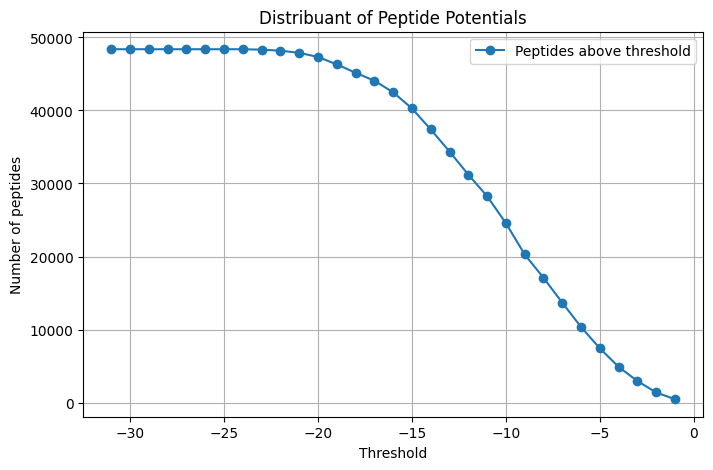

Top 107999 peptides by similarity score:
  FYYKRFTWITFLKL: 0.000
  FYQKRFIWITFLKL: 0.000
  YYYKRFIWITFLKL: 0.000
  FYYKRFIWITFNKL: 0.000
  FYYKRFIWITFLWL: 0.000
  FYYKRFIWHTFLKL: 0.000
  FYYKRFIWITFEKL: 0.000
  FYYKRFIWITFIKL: 0.000
  HYYKRFIWITFLKL: 0.000
  VYYKRFIWITFLKL: 0.000


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- Distribuant function for potentials_dict ---
def plot_potential_distribuant(potentials_dict, thresholds=range(0, 31)):
    values = np.array(list(potentials_dict.values()))
    counts = [np.sum(values > t) for t in thresholds]
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, counts, marker='o', label='Peptides above threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Number of peptides')
    plt.title('Distribuant of Peptide Potentials')
    plt.grid(True)
    plt.legend()
    plt.show()
    return counts

# --- Mutation count calculation (deduplicate per position) ---
def mutation_count(mutations):
    cleaned = {pos: list(set(muts)) for pos, muts in mutations.items()}
    total = np.prod([len(muts) for muts in cleaned.values()])
    identity = 1  # Only the original sequence
    return total - identity

# --- Use top_k equal to mutation count for logprob potential ---
num_mutations = mutation_count(mutations)
print(f"Total possible mutations (Cartesian product minus identity, deduplicated): {num_mutations}")

# Plot distribuant for potentials_dict
plot_potential_distribuant(potentials_dict, thresholds=range(-31, 0))

# For similarity: show top_k using sequences and scores
if 'sequences' in locals() and 'scores' in locals():
    sorted_indices = np.argsort(scores)[::-1]
    top_sequences = [sequences[i] for i in sorted_indices[:num_mutations]]
    top_scores = [scores[i] for i in sorted_indices[:num_mutations]]
    print(f"Top {num_mutations} peptides by similarity score:")
    for seq, score in zip(top_sequences[:10], top_scores[:10]):
        print(f"  {seq}: {score:.3f}")


In [ ]:
# Plot distribuant curves for all peptides in the peps list
import matplotlib.pyplot as plt
import numpy as np

thresholds = range(-31,0)
plt.figure(figsize=(10, 6))

for pep in peps[:5]:
    pep_len = len(pep)
    z = hydramp.encode_peptides([pep])
    jac = decoder_jacobian(
        lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
        z,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )
    U, S, V = torch.linalg.svd(jac, full_matrices=False)
    mutations = get_mutations_from_s_u_standard(
        s=S[0].detach().cpu().numpy(),
        u=U[0].detach().cpu().numpy(),
        max_len=25,
        alphabet_size=21,
        direction_significance_threshold=1e-4,
        min_number_of_directions=5,
        token_threshold=1e-4,
    )
    mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
    alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

    tangent_space = SubRiemannianTangentSpace(
        U=U[0], S=S[0], V=V[0], horizontal_threshold=1e-4, device="cpu"
    )
    potential = ProjectedDirectionPairwiseSimilarityPotential(tangent_space=tangent_space)
    potentials_dict = potential.compute_with_identities(pep, mutations)
    print(f"Peptide: {pep}, Total mutations: {mutation_count(mutations)}, Potentials computed: {len(potentials_dict)}")

    values = np.array(list(potentials_dict.values()))
    counts = [np.sum(values > t)/len(values) for t in thresholds]
    plt.plot(thresholds, counts, marker='o', label=pep)

plt.xlabel('Threshold')
plt.ylabel('Number of peptides')
plt.title('Distribuant of Peptide Potentials for All Peptides')
plt.grid(True)
plt.legend()
plt.show()


Peptide: FLYKWWIRIGRLKL, Total mutations: 191, Potentials computed: 1049
Peptide: KYCRRFRWLTFRWL, Total mutations: 59, Potentials computed: 89


In [ ]:
# Plot distribuant curves for all peptides in the peps list using DecoderLogProbPotential
import matplotlib.pyplot as plt
import numpy as np

thresholds = range(-31, 0)
plt.figure(figsize=(10, 6))

for pep in peps[:5]:
    pep_len = len(pep)
    z = hydramp.encode_peptides([pep])
    jac = decoder_jacobian(
        lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
        z,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )
    U, S, V = torch.linalg.svd(jac, full_matrices=False)
    mutations = get_mutations_from_s_u_standard(
        s=S[0].detach().cpu().numpy(),
        u=U[0].detach().cpu().numpy(),
        max_len=25,
        alphabet_size=21,
        direction_significance_threshold=1e-4,
        min_number_of_directions=5,
        token_threshold=1e-4,
    )
    mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
    alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

    potential_logprob = DecoderLogProbPotential(encoder_decoder=hydramp)
    df = compose_mutant_distribution(
        parent_peptide=pep,
        mutations=mutations,
        potential=potential_logprob,
        include_parent_residue=True,
        top_k=None,
    )
    print(f"Peptide: {pep}, Total mutations: {mutation_count(mutations)}, Mutants computed: {len(df.sequences)}")

    values = np.array(df.log_potentials)
    counts = [np.sum(values > t)/len(values) for t in thresholds]
    plt.plot(thresholds, counts, marker='o', label=pep)

plt.xlabel('Threshold')
plt.ylabel('Fraction of peptides')
plt.title('Distribuant of Decoder LogProb Potentials for All Peptides')
plt.grid(True)
plt.legend()
plt.show()
